# The Stock-Bond Correlation Flip — does its sign tell you when 60/40 breaks? 🪢
### When bonds stop hedging stocks, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

For twenty years, stocks and bonds moved *opposite* each other: when stocks fell, bonds rose, so a classic **60% stocks / 40% bonds** portfolio had a built-in shock absorber. Then **2022** happened — inflation surged, and stocks *and* bonds fell **together**. The 60/40 had its worst year in generations. The technical way to say it: the **stock-bond correlation flipped from negative to positive**.

So here's the folk trading rule we test: *watch the sign of that correlation. When it goes positive, your bond hedge has stopped working — cut your 60/40 (de-risk).* Does the sign actually warn you in time, and does acting on it help?

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from equity_bond_corr_flip import data, strategy as st

def load_real():
    """Cache-first real monthly panel (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return pd.DataFrame()
    return data.monthly_from_prices(px)

M = load_real()
HAVE_REAL = not M.empty
print("real SPY/TLT monthly panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(M)} months, {M.index.min().date()} -> {M.index.max().date()})")


real SPY/TLT monthly panel present: True (286 months, 2002-08-31 -> 2026-05-31)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does 60/40 do better after 'hedge working' (negative-corr) months? | **Yes, a little.** **+0.885%/mo** after negative-corr months vs **+0.566%/mo** after positive-corr ones — the right direction. |
| Is that gap real or noise? | **Can't tell it from noise.** The statistical test scores *t* = 0.89 (you need ~2), and a shuffle test gives *p* = 0.36. |
| Did the signal at least flag 2022? | **Yes.** The correlation went positive in early 2021 and stayed positive all through 2022 (a **-14.0%** year for 60/40). |
| So should you time it? | **Only as a brake, not a gas pedal.** De-risking on the flip cut the worst drawdown (**-28.5% → -23.6%**) but *cost* **-1.84%/yr** of return. |

> The flip is real and the signal saw it — but 'de-risk on positive correlation' is a risk *reducer*, not a money maker, and the whole idea leans on a single big regime change in 24 years of data.

## 1 · The claim

> *"When the stock-bond correlation flips positive, the 60/40 hedge stops working — so cut your exposure."*

Why it *should* matter: the entire appeal of adding bonds to a stock portfolio is diversification — bonds are supposed to zig when stocks zag. That only works when the two are **negatively** correlated. If they start falling together (positive correlation), the 40% in bonds no longer cushions anything, and your 'balanced' portfolio is just a slightly-less-volatile stock portfolio. 2022 was the poster child.

## 2 · So what?

If the *sign* of a slow-moving correlation could warn you before the hedge fails, every risk-parity and 60/40 investor on Earth would want it. It's the cleanest possible market-timing story: one number, one sign, one decision. The desk has looked at the *broad* correlation regime ([578](../../578-cross-asset-correlation-regime/)) and at correlation as a stock-picking signal ([502](../../502-betting-against-correlation/)); here we go straight at **the one pair that matters for 60/40** — stocks vs bonds.

## 3 · How would we even know?

1. **Measure the correlation sign.** Each month, look at the last 6 months of SPY (stocks) and TLT (long bonds) returns and ask: are they moving together (positive) or opposite (negative)?
2. **Look forward.** Split every month into 'negative-corr' and 'positive-corr', then compare how the 60/40 did *the next month*.
3. **Test the rule.** Would de-risking whenever the sign is positive have helped — in return, in volatility, in the worst drawdown?

Catch: the famous flip is essentially **one event** (2022). You can't learn much about 'when regimes change' from a single change — a limitation we keep front and centre.

*Timing:* the correlation sign this month uses only the past 6 months (fully known today); we act on it starting today and hold one month. No peeking at the future.

## 4 · The teardown — let's actually look

**Does 60/40 really do better after 'hedge-working' months?**

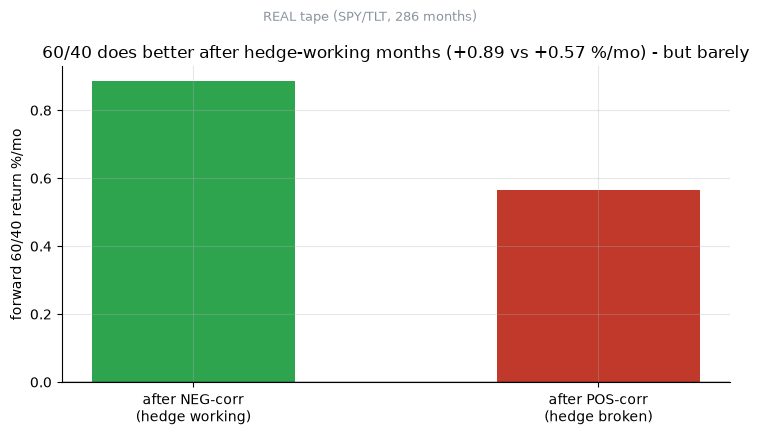

neg +0.885%/mo | pos +0.566%/mo | spread +0.319%/mo | t +0.89 | placebo p 0.361


In [2]:
if HAVE_REAL:
    sp = st.regime_split(M, 'fwd_6040'); ts = st.split_tstat(sp)
    p = st.placebo_pvalue(M, 'fwd_6040', 2000, 579)
    neg_m, pos_m, spr, t = sp['neg_mean']*100, sp['pos_mean']*100, sp['spread']*100, ts['t']
    banner = f'REAL tape (SPY/TLT, {len(M)} months)'
else:
    neg_m, pos_m, spr, t, p = 0.885, 0.566, 0.319, 0.89, 0.36
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['after NEG-corr\n(hedge working)','after POS-corr\n(hedge broken)'], [neg_m, pos_m],
       color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward 60/40 return %/mo')
ax.set_title(f'60/40 does better after hedge-working months (+{neg_m:.2f} vs +{pos_m:.2f} %/mo) - but barely')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'neg +{neg_m:.3f}%/mo | pos +{pos_m:.3f}%/mo | spread {spr:+.3f}%/mo | t {t:+.2f} | placebo p {p:.3f}')

So the direction is **right** — 60/40 earns more after the hedge-is-working months (+0.885%/mo vs +0.566%/mo). But look at the *t*-stat: **0.89**, nowhere near the ~2 you'd want, and the shuffle test says *p* = 0.36. The gap is real in sign but drowned in noise.

**Is the sign at least *stable*?** Run the same split over different eras:

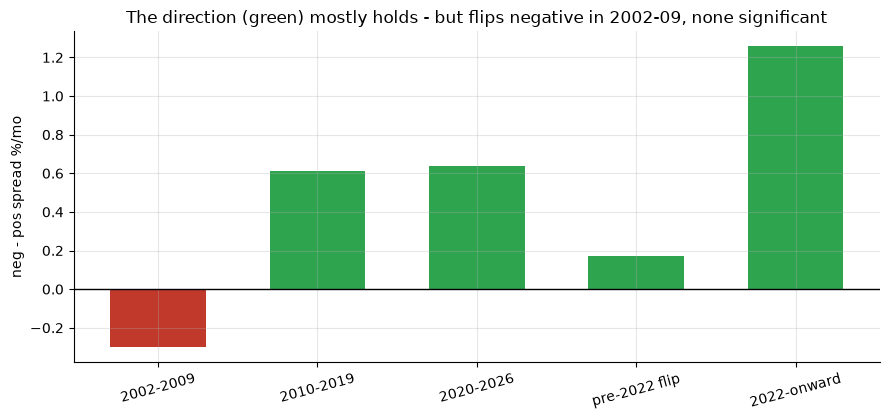

spreads by window: [-0.3, 0.613, 0.636, 0.174, 1.257]


In [3]:
wins = [('2002-2009', -0.3), ('2010-2019', 0.613), ('2020-2026', 0.636), ('pre-2022 flip', 0.174), ('2022-onward', 1.257)]
if HAVE_REAL:
    spans = [('2002-08-31','2009-12-31'),('2010-01-01','2019-12-31'),
             ('2020-01-01','2026-05-31'),('2002-08-31','2021-12-31'),('2022-01-01','2026-05-31')]
    labs = [w[0] for w in wins]; spr = []
    for (sp0,en) in spans:
        s = st.regime_split(M.loc[sp0:en], 'fwd_6040')
        spr.append(s['spread']*100 if s else np.nan)
else:
    labs = [w[0] for w in wins]; spr = [w[1] for w in wins]
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if s>0 else RED for s in spr]
ax.bar(range(len(labs)), spr, color=cols, width=.6)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=15)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('neg - pos spread %/mo')
ax.set_title('The direction (green) mostly holds - but flips negative in 2002-09, none significant')
plt.tight_layout(); plt.show()
print('spreads by window:', [round(s,3) for s in spr])

The bars are *mostly* the folklore direction (green), but the earliest era (2002-09) is the **wrong** sign, and no window is statistically convincing. Worse, the biggest bar (2022-onward) rests on just **4** negative-correlation months — you can't measure a before/after contrast from 4 data points on one side.

**But did the signal at least catch 2022 in time — and did de-risking help?**

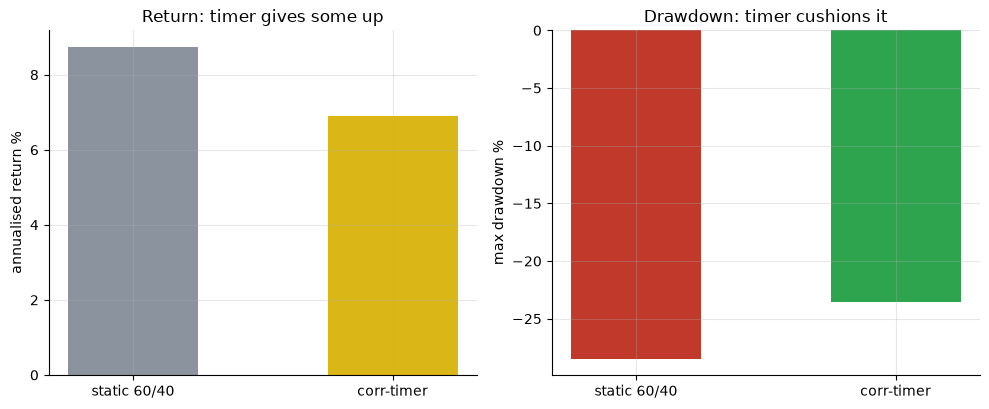

return 8.75% -> 6.90%/yr | max drawdown -28.5% -> -23.6%


In [4]:
if HAVE_REAL:
    tim = st.timer_overlay(M, cost_bps=5.0, derisk_to='bond')
    s_ann, t_ann = tim['static_ann']*100, tim['timer_net_ann']*100
    s_mdd, t_mdd = None, None
    df = M.dropna(subset=['fwd_6040']); rr = df['fwd_6040'].to_numpy()
    sign = df['corr_sign'].to_numpy(); stance = np.where(sign>0, 0.4, 1.0)
    tr = stance*rr
    def mdd(x):
        c=np.cumprod(1+x); pk=np.maximum.accumulate(c); return float((c/pk-1).min())
    s_mdd, t_mdd = mdd(rr)*100, mdd(tr)*100
else:
    s_ann, t_ann, s_mdd, t_mdd = 8.75, 6.9, -28.5, -23.6
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
ax[0].bar(['static 60/40','corr-timer'], [s_ann, t_ann], color=[GREY, AMBER], width=.5)
ax[0].set_ylabel('annualised return %'); ax[0].set_title('Return: timer gives some up')
ax[1].bar(['static 60/40','corr-timer'], [s_mdd, t_mdd], color=[RED, GREEN], width=.5)
ax[1].set_ylabel('max drawdown %'); ax[1].set_title('Drawdown: timer cushions it')
plt.tight_layout(); plt.show()
print(f'return {s_ann:.2f}% -> {t_ann:.2f}%/yr | max drawdown {s_mdd:.1f}% -> {t_mdd:.1f}%')

There's the honest picture. De-risking on the positive-correlation signal **did** cushion the crash — max drawdown improved **-28.5% → -23.6%** — because the signal really was positive through all of 2022's **-14.0%** 60/40 year. But it **cost return**: 8.75% → 6.9%/yr, because the smaller book also sat out much of the 2023-25 recovery. A brake, not a gas pedal.

## 5 · The verdict

- **Signal — Weak.** Right direction (+0.885% vs +0.566%/mo) but *t* 0.89 (placebo *p* 0.36), and the sign flips in the earliest era. The mechanism is real; the tape can't certify a bankable edge.
- **Tradability — Fragile.** A de-risking overlay that cuts drawdown (-28.5% → -23.6%) and vol (9.9% → 7.1%) but costs -1.84%/yr of return — a risk tool, not alpha, resting on one regime change.

## 6 · Could you actually trade it?

As a *risk* rule, sort of — de-risking when the correlation is positive genuinely trimmed the 2022 drawdown, and it nudged the risk-adjusted return (Sharpe) up a hair. As a *return* rule, no — you give up ~1.8%/yr for that comfort, and across a full cycle the return you sacrifice outweighs the drawdown you save. And remember: the entire case leans on **one** flip (2022). One correct call is not an edge you can compound.

## 7 · Going further 🚪

- **The broad version.** [578 Cross-Asset-Correlation-Regime](../../578-cross-asset-correlation-regime/) does this for the *whole* correlation matrix, not just stocks vs bonds.
- **The drivers.** [152 Inflation-Hedge](../../152-inflation-hedge/) and [119 Real-Rate-Regime](../../119-real-rate-regime/) are the macro forces *behind* the flip.

*Think the flip is a tradable timer? Fork this, add more regime changes (1970s inflation, if you can source the data), and show the neg-minus-pos spread clearing t = 2 out of sample.*